<a href="https://colab.research.google.com/github/Navya28-khanna/ML_LAB/blob/main/SVM_German_credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
%matplotlib inline

In [4]:
# Load the German Credit dataset from your folder
df = pd.read_csv("german credit.data.txt", sep=' ', header=None)

# Assign column names
columns = [
'status','duration','credit_history','purpose','credit_amount','savings',
'employment','installment_rate','personal_status','other_debtors',
'residence','property','age','other_installment','housing',
'existing_credits','job','num_people','telephone','foreign_worker','target'
]

df.columns = columns

# Convert target (1 = Good, 2 = Bad) → (0 = Good, 1 = Bad)
df['target'] = df['target'].apply(lambda x: 0 if x==1 else 1)

# Check dataset information
print(df.info())
print(df.describe())

# Check missing values
print("Missing values count:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   status             1000 non-null   object
 1   duration           1000 non-null   int64 
 2   credit_history     1000 non-null   object
 3   purpose            1000 non-null   object
 4   credit_amount      1000 non-null   int64 
 5   savings            1000 non-null   object
 6   employment         1000 non-null   object
 7   installment_rate   1000 non-null   int64 
 8   personal_status    1000 non-null   object
 9   other_debtors      1000 non-null   object
 10  residence          1000 non-null   int64 
 11  property           1000 non-null   object
 12  age                1000 non-null   int64 
 13  other_installment  1000 non-null   object
 14  housing            1000 non-null   object
 15  existing_credits   1000 non-null   int64 
 16  job                1000 non-null   object
 

/tmp/ipykernel_373/4043333068.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='RdBu_r')


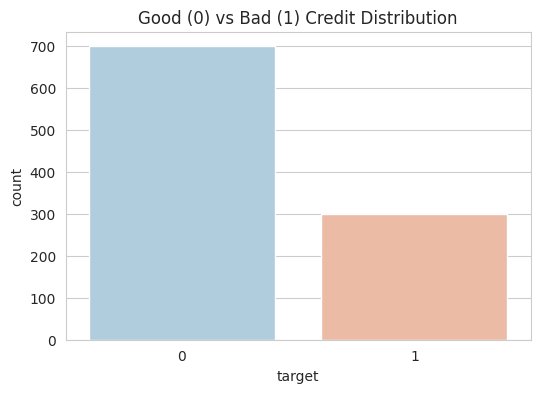

/tmp/ipykernel_373/4043333068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='winter')


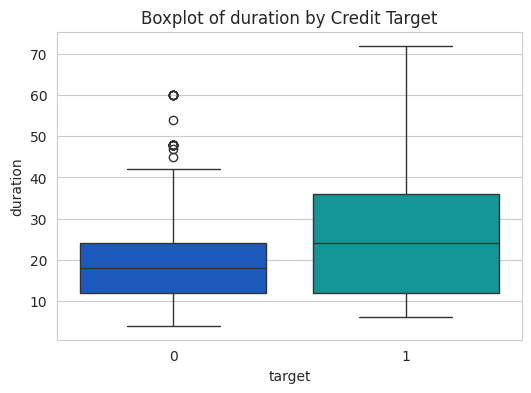

/tmp/ipykernel_373/4043333068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='winter')


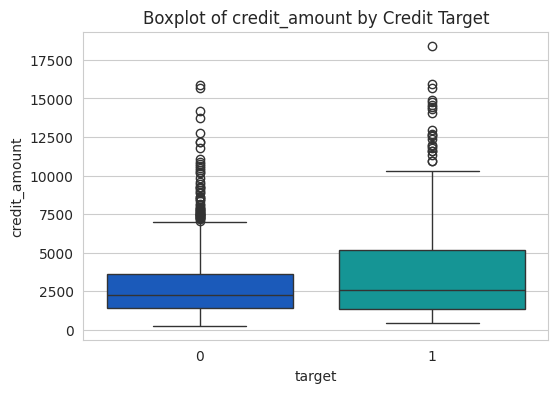

/tmp/ipykernel_373/4043333068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='winter')


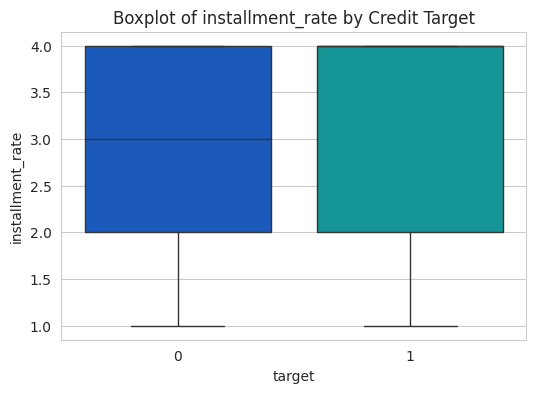

/tmp/ipykernel_373/4043333068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='winter')


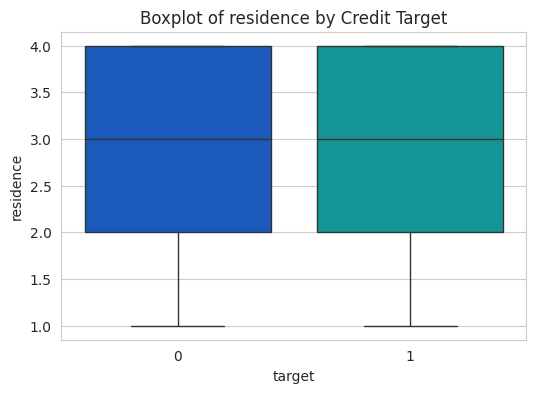

/tmp/ipykernel_373/4043333068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, palette='winter')


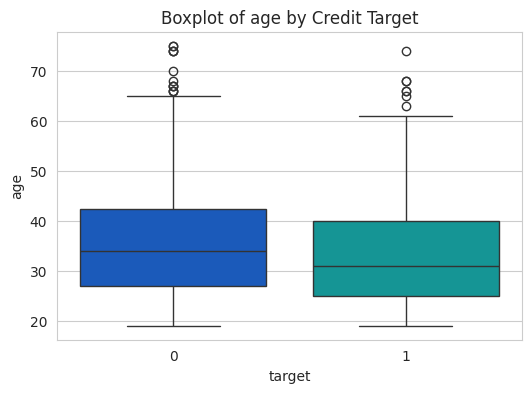

In [5]:
# Set seaborn style
sns.set_style('whitegrid')

# Plot distribution of Good vs Bad credit
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='RdBu_r')
plt.title('Good (0) vs Bad (1) Credit Distribution')
plt.show()

# Boxplots for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns[:5]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df, palette='winter')
    plt.title(f'Boxplot of {col} by Credit Target')
    plt.show()

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
X = df.drop('target', axis=1)
y = df['target']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [14]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

SVC()

In [15]:
predictions = model.predict(X_test)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[203   1]
 [ 89   7]]
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       204
           1       0.88      0.07      0.13        96

    accuracy                           0.70       300
   macro avg       0.79      0.53      0.48       300
weighted avg       0.75      0.70      0.60       300



In [16]:
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1)
grid.fit(X_train, y_train)

# Performance analysis of the improved model
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test, grid_predictions))
print(classification_report(y_test, grid_predictions))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[[204   0]
 [ 96   0]]
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       204
           1       0.00      0.00      0.00        96

    accuracy                           0.68       300
   macro avg       0.34      0.50      0.40       300
weighted avg       0.46      0.68      0.55       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
